# Lecture 1 – Digital Image Fundamentals with OpenCV
 
Course: Computer Vision  
Topic: Image Representation and Basic Processing

## 1️⃣ Reading an Image

### What is a digital image?

A digital image is a discrete representation of visual information.
It is composed of small elements called **pixels** arranged in a grid.

Each pixel contains intensity values:

- Grayscale → 1 value per pixel
- Color (RGB/BGR) → 3 values per pixel

Mathematically, an image can be represented as a function:

                                                        I(x, y) → ℝᶜ

Where:
- x, y → spatial coordinates
- c → number of channels

In [ ]:
# Import required libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [10]:
# Read image from file

img = cv2.imread('gunter.jpg')
 
print("Image loaded successfully")

Image loaded successfully


## 2️⃣ Checking Image Attributes

We analyze the internal structure of the image stored in memory.

Important attributes:

- shape → (height, width, channels)
- dtype → data type (usually uint8)
- size → total number of elements
- min / max → intensity range
- mean → average intensity

In [11]:
print("=== IMAGE ATRIBUTES ===")
print(f"Shape: {img.shape}")          
print(f"dtype: {img.dtype}")           
print(f"Size: {img.size}")             
print(f"Min: {img.min()}")             
print(f"Max: {img.max()}")            
print(f"Mean: {img.mean():.2f}")      

=== IMAGE ATRIBUTES ===
Shape: (204, 204, 3)
dtype: uint8
Size: 124848
Min: 0
Max: 255
Mean: 174.38


## 3️⃣ Format and Palette Information

When OpenCV loads an image:

- It decodes the file (JPG, PNG, etc.)
- It converts the image into a NumPy array
- It uses BGR color space by default

OpenCV does not use indexed color palettes.
It works with direct color representation (0–255 per channel).

In [12]:
print("=== FORMAT INFORMATION ===")

# Number of dimensions
print(f"Number of dimensions: {len(img.shape)}")

# Channel information
if len(img.shape) == 2:
    print("Format: Grayscale image (1 channel)")
elif len(img.shape) == 3:
    print(f"Format: Color image with {img.shape[2]} channels")

print("Color space: BGR (OpenCV default)")
print(f"Bit depth: {img.itemsize * 8} bits per channel")

=== FORMAT INFORMATION ===
Number of dimensions: 3
Format: Color image with 3 channels
Color space: BGR (OpenCV default)
Bit depth: 8 bits per channel


## 4️⃣ Matrix Representation in NumPy

An image in OpenCV is stored as a NumPy array.

Color image → 3D array:
(height, width, channels)

Grayscale image → 2D array:
(height, width)

Each element corresponds to pixel intensity values.

In [13]:
print("=== MATRIX REPRESENTATION ===")

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

print("Grayscale shape:", gray.shape)
print("Top-left 3x3 grayscale matrix:")
print(gray[:3, :3])

print("\nColor image shape:", img.shape)
print("Top-left 2x2x3 color matrix:")
print(img[:2, :2])

=== MATRIX REPRESENTATION ===
Grayscale shape: (204, 204)
Top-left 3x3 grayscale matrix:
[[222 222 222]
 [222 222 222]
 [222 222 222]]

Color image shape: (204, 204, 3)
Top-left 2x2x3 color matrix:
[[[255 245 165]
  [255 245 165]]

 [[255 245 165]
  [255 245 165]]]


## 5️⃣ Color Channels (Splitting and Merging)

A color image can be separated into three channels:

- Blue
- Green
- Red

Each channel is a 2D matrix representing intensity for that color.

Why BGR?

OpenCV uses BGR instead of RGB due to historical reasons related to legacy systems.

In [14]:
print("=== CHANNEL SPLITTING ===")

# SPLIT image into 3 separate matrices
blue, green, red = cv2.split(img)  # BGR order!

print(f"Original: {img.shape}")      # (480,640,3)
print(f"Blue channel shape: {blue.shape}")         # (480,640) ← 2D!
print(f"Green channel shape: {green.shape}")
print(f"Red channel shape: {red.shape}")

# SEE 2x2 CORNER of each channel
print("\nTop-left 2x2 Blue channel:\n", blue[:2,:2])
print("Top-left 2x2 Green channel:\n", green[:2,:2])
print("Top-left 2x2 Red channel:\n", red[:2,:2])


=== CHANNEL SPLITTING ===
Original: (204, 204, 3)
Blue channel shape: (204, 204)
Green channel shape: (204, 204)
Red channel shape: (204, 204)

Top-left 2x2 Blue channel:
 [[255 255]
 [255 255]]
Top-left 2x2 Green channel:
 [[245 245]
 [245 245]]
Top-left 2x2 Red channel:
 [[165 165]
 [165 165]]


Color Image, mergeing channels

In [15]:
# Merge channels back
reconstructed = cv2.merge([blue, green, red])

print("Reconstructed shape:", reconstructed.shape)
print("Is identical to original?", np.array_equal(img, reconstructed))

Reconstructed shape: (204, 204, 3)
Is identical to original? True


## 6️⃣ Displaying Images with Matplotlib

Matplotlib uses RGB format,
while OpenCV uses BGR.

Therefore, we must convert:

BGR → RGB

before displaying the image.


=== ⑥ MATPLOTLIB DISPLAY ===


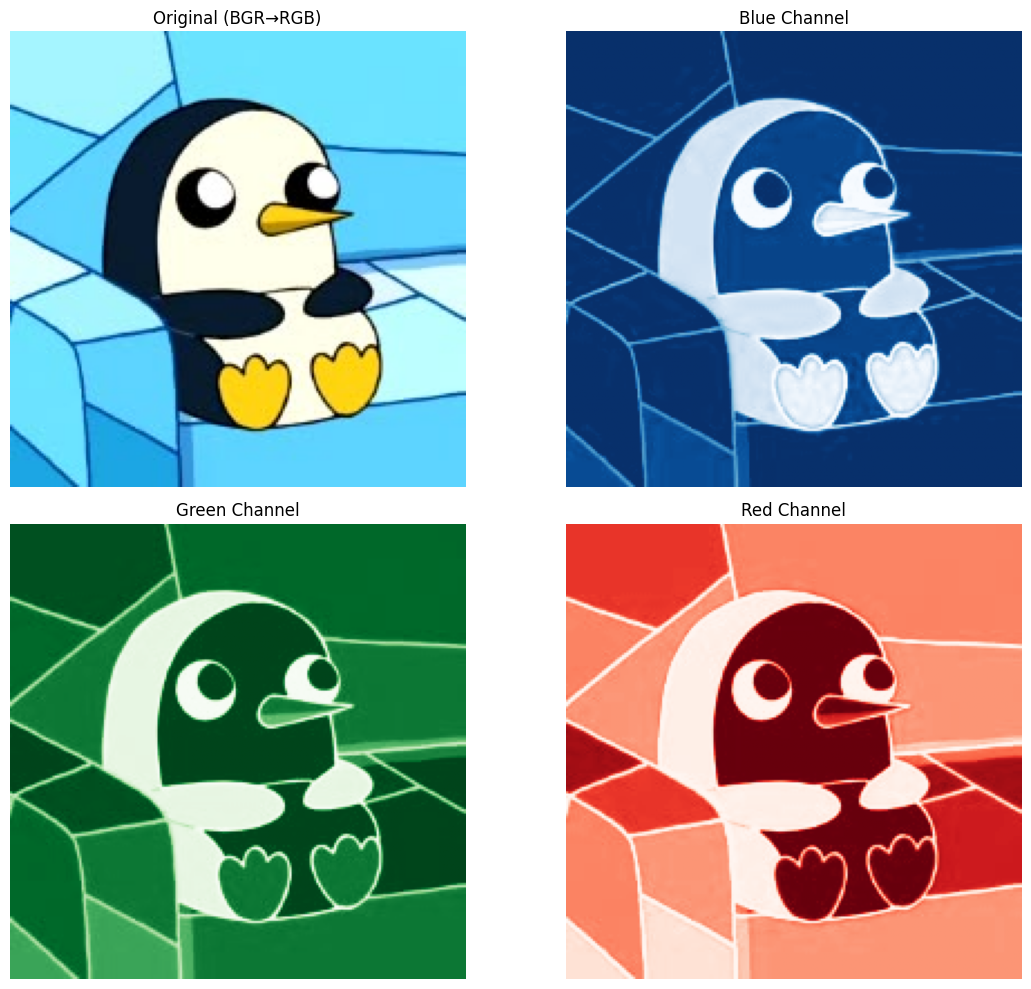

In [16]:
print("\n=== ⑥ MATPLOTLIB DISPLAY ===")

# Convert BGR to RGB for proper display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#  Figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Original
axes[0,0].imshow(img_rgb)
axes[0,0].set_title('Original (BGR→RGB)')
axes[0,0].axis('off')

# 2. Blue Only
axes[0,1].imshow(blue, cmap='Blues')
axes[0,1].set_title("Blue Channel")
axes[0,1].axis("off")

# 3. Green Only
axes[1,0].imshow(green, cmap='Greens')
axes[1,0].set_title("Green Channel")
axes[1,0].axis("off")

# 4. Red Only 
axes[1,1].imshow(red, cmap='Reds')
axes[1,1].set_title("Red Channel")
axes[1,1].axis("off")

plt.tight_layout()
plt.show()


## 7️⃣ Saving Images

We can store processed images using cv2.imwrite().

This function writes a NumPy array back to an image file.

In [17]:
print("\n=== ⑦ SAVING IMAGES ===")

# Guardar original RGB
cv2.imwrite('original_processed.jpg', img)

# save ONLY blue channel (as grays)
cv2.imwrite('blue_only.jpg', blue)

# save rebuilt
cv2.imwrite('rebuilt.jpg', reconstructed)

# Check saved
print("✅ Saved:")
print("  • original_processed.jpg")
print("  • blue_only.jpg") 
print("  • rebuilt.jpg")

# INFO files
print(f"Original size: {img.nbytes} bytes")
print(f"Blue size: {blue.nbytes} bytes")



=== ⑦ SAVING IMAGES ===
✅ Saved:
  • original_processed.jpg
  • blue_only.jpg
  • rebuilt.jpg
Original size: 124848 bytes
Blue size: 41616 bytes
